In [1]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
pd.set_option('display.max_columns', None)
import time
import warnings
warnings.filterwarnings("ignore")
import os
import sys

In [2]:
import data_utils
import models

In [3]:
from utils import xgb_eval, lgbm_eval, catb_eval
from expl_utils import inverse_transform_rule_complete

# Load Dataset

In [4]:
# dataset_name= 'adult'
dataset_name= 'compas'
# dataset_name= 'fico'
# dataset_name= 'churn'
# dataset_name= 'breast'

data_dict = data_utils.get_tabular_dataset(dataset_name, random_state=42)

In [5]:
X_train, X_test, y_train, y_test = data_dict['X_train'], data_dict['X_test'], data_dict['y_train'], data_dict['y_test']

In [6]:
features_map = data_dict['features_map']
idx_num_cat = [list(d.values()) for i,d in features_map.items()]

# Train Black-Box

In [ ]:
clf, clf_score = lgbm_eval(X_train, y_train, X_test, y_test, random_state=42)
print(clf_score)

In [9]:
y_train_pred = clf.predict_proba(X_train)
y_test_pred = clf.predict_proba(X_test)

# Latent Encoding Training

## Run the code for training a dense meta-encoding.

encdec=
- 'linear' : for a single global linear transformation
- 'local_linear':  for individual linear transformations

In [48]:
latent = models.ILLUME(encdec='local_linear', max_epochs=1000, latent_dim=16, batch_size=1024, early_stopping=30)

Important inputs:
- X=(X_train, X_test) : train/validation sets for validation accuracy / early stopping
- y=(y_train_pred, y_test_pred) : predicted black-box probabilities (optional)
- idx_num_cat : list of lists with numerical/categorical features indices
- params_dict : dictionary with regularization parameters

Keys in params_dict:
- 'num_k': number of non-zero weights per row in the encoder transformation matrix. None means all non-zero weights  
- 'l_so': set to 1.0 to enable orthogonalization of the encoder transformation matrix (only if 'num_k'!= None) 
- 'l_rec': set to 1.0 to enable training a non-linear decoder 
- 'l_kld': set to 1.0 to optimize distances distribution
- 'l_co': set to 1.0 to optimize non-collinearity of latent features
- 'l_st': set to 1.0 to optimize local stability of individual linear transformations (only if encdec='param_encdec')

In [ ]:
losses = latent.fit(X=(X_train, X_test),                   
                    y=(y_train_pred, y_test_pred),               
                    idx_num_cat=idx_num_cat,                       
                    params_dict={'num_k':None, 'l_rec':0.0, 'l_kld':1.0,      # dictionary with regularization parameters
                            'l_so':0.0, 'l_co':1.0, 'l_st':1.0},
                    seed=42)

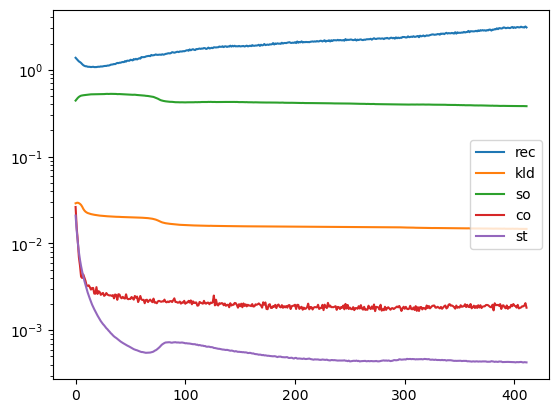

In [12]:
# plt.plot(np.array(losses[0])[:,:-1], label=['rec', 'kld', 'so', 'co', 'st'])
plt.plot(np.array(losses[1])[:,:-1], label=['rec', 'kld', 'so', 'co', 'st'])
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Space Z')

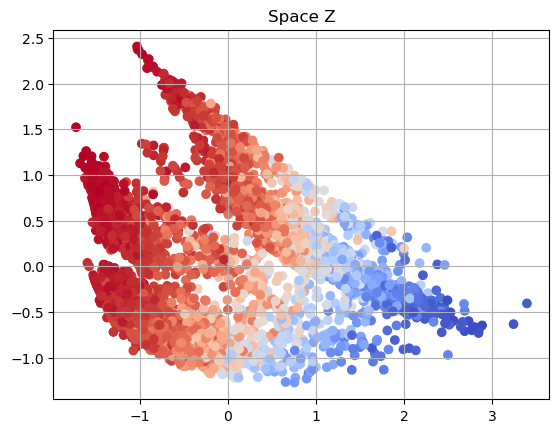

In [13]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

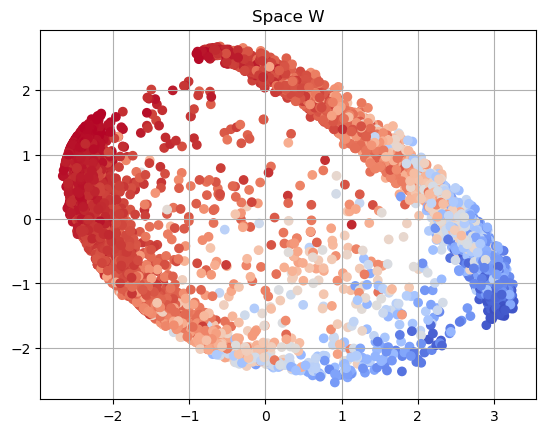

In [14]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Latent Encoding with Sparsity

### The code here should be run after pre-training dense meta-encoding in the previous section. Skip this section if you are not interested in sparsity constraints.

In [ ]:
#tune sparse model by incrementally adding sparsity every 30 epochs

losses = latent.fit(X=(X_train, X_test),                   # train/test sets for validation accuracy / early stopping 
                    y=(y_train_pred, y_test_pred),               # predicted probabilities 
                    idx_num_cat=idx_num_cat,                      # numerical/categorical indices 
                    params_dict={'num_k':2, 'l_rec':0.0, 'l_kld':1.0,         # dictionary with regularization parameters
                            'l_so':1.0, 'l_co':1.0, 'l_st':1.0},
                    seed=42)

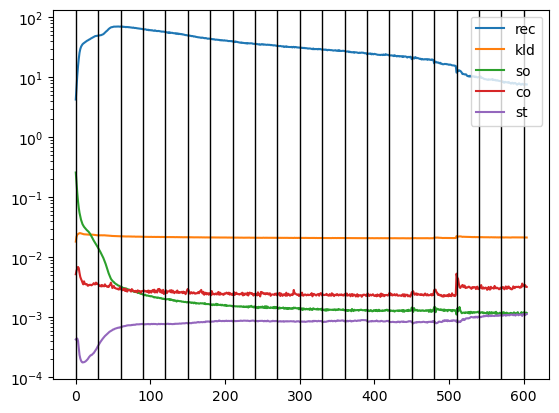

In [16]:
# plt.plot(np.array(losses[0])[:,:-1], label=['rec', 'kld',  'so', 'co', 'st'])
plt.plot(np.array(losses[1])[:,:-1], label=['rec' ,'kld',  'so', 'co', 'st'])
for i in range(len(losses[0])//30+1):
    plt.axvline(x = 30*i, color = 'k', linewidth=1)
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Space Z')

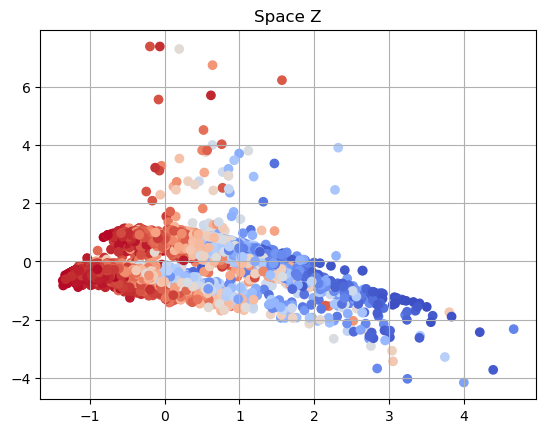

In [17]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

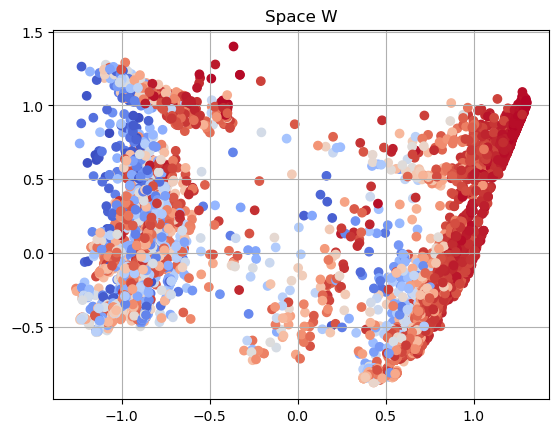

In [18]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Local Explanations

In [51]:
y_train_bb = clf.predict(X_train)
y_test_bb = clf.predict(X_test)

## Feature importance

In [52]:
latent.explain_linear(num_k=2)

Training Logistic Regression surrogate.
LR surrogate score: 0.9044
Generating feature importance for training set.



In [53]:
fimp = latent.get_feature_importance(X_test, y_test_bb, num_k=2)

In [54]:
fimp = [{f:ex[i] for i,f in enumerate(data_dict['feature_names'])} for ex in fimp]

In [55]:
fimp = [[(f, ex[f]) for i,f in enumerate(data_dict['feature_names']) 
         if (ex[f]!=0.0) and (f in data_dict['numeric_columns'] or x[i]==1.)] 
        for ex,x in zip(fimp, X_test)]

In [56]:
fimp[0]

[('age', 3.2072008510096963),
 ('priors_count', -4.003289861069839),
 ('days_b_screening_arrest', 0.1638462115662424),
 ('is_recid', -1.378771528221193),
 ('is_violent_recid', 0.9535938463236878),
 ('two_year_recid', 0.4397302845103134),
 ('length_of_stay', -0.1036388580787401),
 ('age_cat=25 - 45', -0.2792795330487746),
 ('sex=Male', 1.820292249825029),
 ('race=African-American', -1.2654610798427186),
 ('c_charge_degree=M', -0.4036405078262066)]

## Decision Rules

In [57]:
latent.explain_dectree(num_k=2)

Training Decision Tree surrogate.
DT surrogate score: 0.9217
Generating factual and counterfactual rules for training set.



##### Factual rules

In [58]:
rules = latent.get_decision_rules(X_test, y_test_bb, num_k=2)

In [59]:
rules = [inverse_transform_rule_complete(ex, data_dict['scaler'], latent.idx_num) for ex in rules]

In [60]:
rules = [{(f,eq): ex[(f'x{i}', eq)] for i,f in enumerate(data_dict['feature_names']) for eq in ['<=', '>'] if (ex[(f'x{i}', eq)] not in [np.inf, -np.inf])} for ex in rules]

In [61]:
rules = [[(f,eq, ex[(f,eq)]) if f in data_dict['numeric_columns'] 
          else (f.split('=')[0], ('=' if eq=='>' else '!='), f.split('=')[1]) 
          for f,eq in ex]
         for ex in rules]

In [99]:
rules[0]

[('age', '<=', 45.589825303736774),
 ('priors_count', '<=', 36.403177967720346),
 ('priors_count', '>', 10.648713267831823),
 ('is_recid', '<=', 0.047608471255086326),
 ('is_violent_recid', '>', -0.039167967601148546),
 ('race', '!=', 'Caucasian'),
 ('c_charge_degree', '=', 'M')]

##### CounterRules/CounterExamples

In [63]:
crules, cfs = latent.get_counterfactuals(X_test, y_test_bb, num_k=2)

In [64]:
crules = [[inverse_transform_rule_complete(cx, data_dict['scaler'], latent.idx_num) for cx in cx_list] for cx_list in crules]

In [65]:
crules = [[{(f,eq): cx[(f'x{i}', eq)] for i,f in enumerate(data_dict['feature_names']) for eq in ['<=', '>'] if (cx[(f'x{i}', eq)] not in [np.inf, -np.inf])} for cx in cx_list] for cx_list in crules]

In [66]:
crules = [[[(f,eq, cx[(f,eq)]) if f in data_dict['numeric_columns'] 
          else (f.split('=')[0], ('=' if eq=='>' else '!='), f.split('=')[1]) 
          for f,eq in cx] for cx in cx_list]
         for cx_list in crules]

In [112]:
crules[0]

[[('age', '>', 33.2641596832888), ('priors_count', '<=', 10.812415986646094)],
 [('age', '>', 28.622809595312468), ('priors_count', '<=', 4.136702652677475)],
 [('c_charge_degree', '!=', 'M')],
 [('priors_count', '>', 10.795541325444727), ('race', '=', 'Caucasian')],
 [('age', '>', 26.85971437657099), ('priors_count', '<=', 3.0104470768776608)],
 [('is_recid', '>', 0.993825570627571),
  ('is_violent_recid', '>', 0.9823411908766784)],
 [('age', '>', 44.98767668508404), ('priors_count', '<=', 8.003765384078292)]]

In [105]:
cfs = [np.concatenate((data_dict['scaler'].inverse_transform(cf[:, latent.idx_num]), cf[:, latent.idx_cat]), axis=1) for cf in cfs]

In [111]:
cfs[0]

array([[39., 10.,  1.,  0.,  0.,  0., 40.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [30.,  4.,  1.,  0.,  0.,  0., 54.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [53., 13.,  1.,  0.,  0.,  0., 91.,  0.,  1.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [26., 11., 56.,  0.,  0.,  0., 56.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  1.,  0.,  0.,  0.,  1.,  0.],
       [27.,  3.,  1.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [19.,  1., 40.,  1.,  1.,  1., 35.,  0.,  0.,  1.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [45.,  8.,  0.,  1.,  0.,  1., 71.,  0.,  1.,  0.,  0.,  1.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  1.]])